### Question to answer: What are the past and future projected distribution of OHCA incidence by location in Singapore? 

Outlining specific area on Google Map using GeoJson

https://www.geeksforgeeks.org/python/outline-specific-area-on-google-map-using-geojson/

In [59]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import io
import msoffcrypto
import openpyxl

In [60]:
import geopandas as gpd
from shapely.geometry import Point

In [14]:
# environment set up
from dotenv import load_dotenv
import os

# use os.getcwd instead of os.path.dirname(__file__) for jupyter notebooks to get the current working directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), "../.."))

load_dotenv(os.path.join(parent_dir, ".env"))

True

In [15]:
pd.set_option("display.max_columns", None)

In [6]:
### Read the paros dataset
filename = "DataExportParos_SG_Apr10-Dec21_with postal codes_27Mar25_encryptedv1.xlsx"
# load password from .env
password = os.getenv("PAROS_PASSWORD")

with open("../../datasets/" + filename, "rb") as encrypted_data:
    paros = msoffcrypto.OfficeFile(encrypted_data)
    paros.load_key(password = password)
    # decrypt file into a BytesIO object
    decrypted = io.BytesIO()
    paros.decrypt(decrypted)

    # use pandas to read the decrypted Excel File
    df = pd.read_excel(decrypted)

/Users/yitong/opt/anaconda3/envs/geopandasNew/lib/python3.9/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Data Validation extension is not supported and will be removed
  for idx, row in parser.parse():


In [16]:
print(df.head())

      Case # Country City  Site # Patient brought in by Date of Incident  \
0  SGSIN0213      SG  SIN       2                   EMS       2010-04-01   
1  SGSIN0218      SG  SIN       2                   EMS       2010-04-01   
2  SGSIN6480      SG  SIN       6                   EMS       2010-04-01   
3  SGSIN5332      SG  SIN       5                   EMS       2010-04-02   
4  SGSIN0214      SG  SIN       2                   EMS       2010-04-03   

   Location of incident Location Unknown        Location Type  \
0              470146.0              NaN       Home Residence   
1              520926.0              NaN       Home Residence   
2              560565.0              NaN  Healthcare Facility   
3              680626.0              NaN       Home Residence   
4              468963.0              NaN  Place of Recreation   

           Location Type Other  Age Age Modifier  Gender     Race  \
0                  HDB Level 7   60        Years    Male  Chinese   
1             

##### What are the percentage of OHCA case where location is unknown
This is for geospatial analysis

Filter for cases where:

- Location Unknown == "yes"


In [17]:
print("total cases in dataset:", df.shape[0])

total cases in dataset: 28665


In [53]:
## where Location of incident == N/A | blank
location_unknown = df[(df["Location of incident"].isnull())]
print("Number of cases with location unknown", location_unknown.shape[0])

## where Location of incident != N/A | blank
location_known = df[df["Location of incident"].notnull()]
print("Number of cases with known postal code", location_known.shape[0])

percentage_unknown = round((location_unknown.shape[0] / df.shape[0] * 100), 2)
print("percentage of cases with unknown location:", str(percentage_unknown) + "%")

Number of cases with location unknown 1038
Number of cases with known postal code 27627
percentage of cases with unknown location: 3.62%


#### Some of the location can be found in location type, will have to filter location_unknown to sieve them out later

Reducing the dataframes to the more important columns. Easier to work with

In [58]:
impt_columns = ["Case #", "Site #", "Date of Incident", "Location Unknown",
                "Location Type", "Location Type Other"]

postal_code_known = location_known[impt_columns].copy()

no_postal_code = location_unknown[impt_columns].copy()

# print(no_postal_code)

Getting a map from Natural Earth


https://colab.research.google.com/github/QuantEcon/quantecon-notebooks-datascience/blob/master/applications/maps.ipynb#scrollTo=4xSATFfrY0Je

In [103]:
world = gpd.read_file("../../../ne_10m_admin_0_countries")

In [102]:
country = ["Singapore"]
result = world[world["SOVEREIGNT"].isin(country)]
print(result)

          featurecla  scalerank  LABELRANK SOVEREIGNT SOV_A3  ADM0_DIF  LEVEL  \
230  Admin-0 country          3          6  Singapore    SGP         0      2   

                  TYPE TLC      ADMIN ADM0_A3  GEOU_DIF    GEOUNIT GU_A3  \
230  Sovereign country   1  Singapore     SGP         0  Singapore   SGP   

     SU_DIF    SUBUNIT SU_A3  BRK_DIFF       NAME  NAME_LONG BRK_A3  \
230       0  Singapore   SGP         0  Singapore  Singapore    SGP   

      BRK_NAME BRK_GROUP ABBREV POSTAL              FORMAL_EN FORMAL_FR  \
230  Singapore      None  Sing.     SG  Republic of Singapore      None   

    NAME_CIAWF NOTE_ADM0 NOTE_BRK  NAME_SORT NAME_ALT  MAPCOLOR7  MAPCOLOR8  \
230  Singapore      None     None  Singapore     None          5          3   

     MAPCOLOR9  MAPCOLOR13    POP_EST  POP_RANK  POP_YEAR  GDP_MD  GDP_YEAR  \
230          7           3  5703569.0        13      2019  372062      2019   

                  ECONOMY               INCOME_GRP FIPS_10 ISO_A2 ISO_A2

In [104]:
list_of_columns = list(world.columns)
print(list_of_columns)

['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3', 'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN', 'ADM0_A3', 'GEOU_DIF', 'GEOUNIT', 'GU_A3', 'SU_DIF', 'SUBUNIT', 'SU_A3', 'BRK_DIFF', 'NAME', 'NAME_LONG', 'BRK_A3', 'BRK_NAME', 'BRK_GROUP', 'ABBREV', 'POSTAL', 'FORMAL_EN', 'FORMAL_FR', 'NAME_CIAWF', 'NOTE_ADM0', 'NOTE_BRK', 'NAME_SORT', 'NAME_ALT', 'MAPCOLOR7', 'MAPCOLOR8', 'MAPCOLOR9', 'MAPCOLOR13', 'POP_EST', 'POP_RANK', 'POP_YEAR', 'GDP_MD', 'GDP_YEAR', 'ECONOMY', 'INCOME_GRP', 'FIPS_10', 'ISO_A2', 'ISO_A2_EH', 'ISO_A3', 'ISO_A3_EH', 'ISO_N3', 'ISO_N3_EH', 'UN_A3', 'WB_A2', 'WB_A3', 'WOE_ID', 'WOE_ID_EH', 'WOE_NOTE', 'ADM0_ISO', 'ADM0_DIFF', 'ADM0_TLC', 'ADM0_A3_US', 'ADM0_A3_FR', 'ADM0_A3_RU', 'ADM0_A3_ES', 'ADM0_A3_CN', 'ADM0_A3_TW', 'ADM0_A3_IN', 'ADM0_A3_NP', 'ADM0_A3_PK', 'ADM0_A3_DE', 'ADM0_A3_GB', 'ADM0_A3_BR', 'ADM0_A3_IL', 'ADM0_A3_PS', 'ADM0_A3_SA', 'ADM0_A3_EG', 'ADM0_A3_MA', 'ADM0_A3_PT', 'ADM0_A3_AR', 'ADM0_A3_JP', 'ADM0_A3_KO', 'ADM0_A3_VN', 'ADM0_A3_TR', 'AD

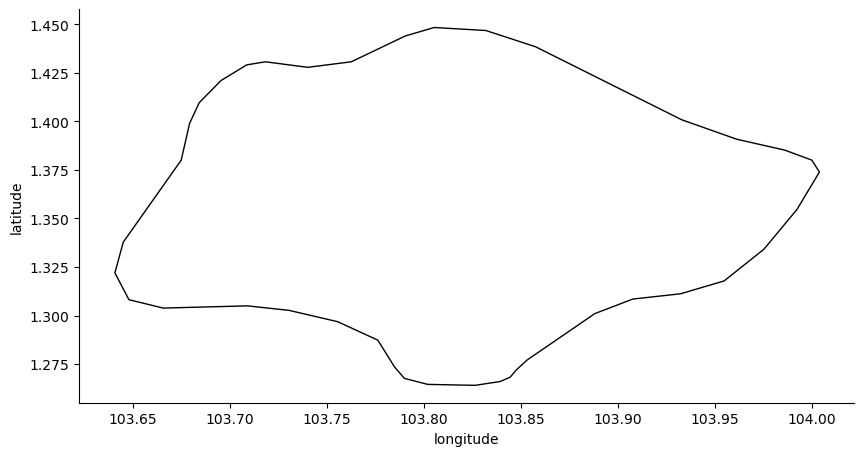

In [105]:
fig, gax = plt.subplots(figsize=(10,10))

world.query("SOVEREIGNT == 'Singapore'").plot(ax = gax, edgecolor='black',color='white')
gax.set_xlabel('longitude')
gax.set_ylabel('latitude')
gax.spines['top'].set_visible(False)
gax.spines['right'].set_visible(False)

plt.show()

In [108]:
locations = pd.DataFrame({
    "City": ["Botanic Gardens"],
    "Latitude": [1.31464],
    "Longitude": [103.81612]
})
## Zip the latitude and longitude together and store in "Coordinates" column
locations["Coordinates"] = list(zip(locations.Longitude, locations.Latitude))
# turn the coordinates tuple into a shapely point object
locations["Coordinates"] = locations["Coordinates"].apply(Point)
locations.head()


,City,Latitude,Longitude,Coordinates
0,Botanic Gardens,1.31464,103.81612,POINT (103.81612 1.31464)


In [111]:
## convert dataframe into geodata frame
gdf = gpd.GeoDataFrame(locations, geometry="Coordinates")
print(gdf.head())

print('gdf is of type:', type(gdf))
print('\nThe geometry column is:', gdf.geometry.name)

              City  Latitude  Longitude                Coordinates
0  Botanic Gardens   1.31464  103.81612  POINT (103.81612 1.31464)
gdf is of type: <class 'geopandas.geodataframe.GeoDataFrame'>

The geometry column is: Coordinates


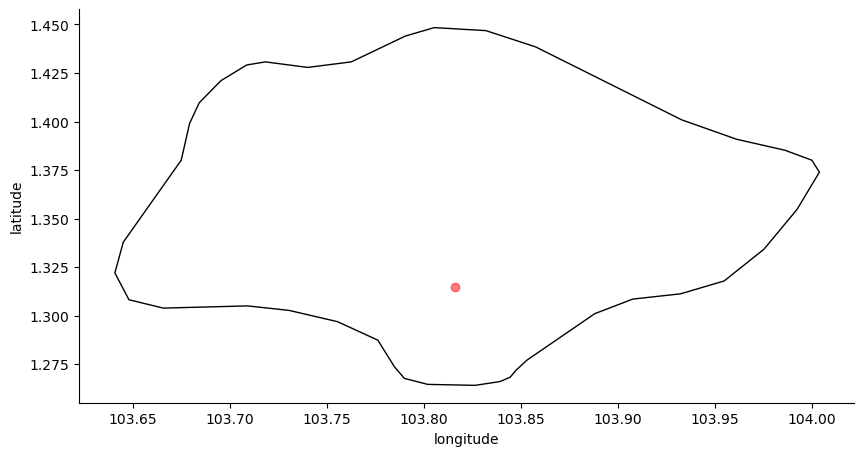

In [112]:
fig, gax = plt.subplots(figsize=(10,10))

world.query("SOVEREIGNT == 'Singapore'").plot(ax = gax, edgecolor='black',color='white')

# this time add in some locations from the geodataframe "locations"
gdf.plot(ax=gax, color='red', alpha = 0.5)

gax.set_xlabel('longitude')
gax.set_ylabel('latitude')
gax.spines['top'].set_visible(False)
gax.spines['right'].set_visible(False)

plt.show()